# Week 6 Day 5 Lab
For the final lab, we'll cover Markov Chain Monte Carlo (MCMC). Recall that Monte Carlo is simply a method of estimating through lots and lots of random sampling. Similarly, MCMC depends on lots of random sampling. However, the *way* we sample is different.

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

### Dependent State Random Sampling
Instead of randomly sampling each point **independently**, we make the next sample **depend** on what we just sampled previously. Much like your next move in chess might be random, your next move is very dependent on where the pieces are placed currently.

In [4]:
target = [0.01, 0.01, 0.01, 0.07, 0.9]

In [5]:
def mcmc(steps, target):
    distance = []
    n = len(target)                                   # number of options
    current = np.random.choice([i for i in range(n)])       # random current starting option
    
    samples = [current]
    for i in range(steps):
        proposal = np.random.choice([i for i in range(n)])      # choose a proposed next step
        a = min(1, target[proposal] / target[current])   # how good is the proposed step compared to current step?
        
        # if a is better than a uniform at random choice, move to the proposed step!
        if np.random.uniform(0,1) < a:              
            current = proposal                          
            currestimate = np.bincount(samples, minlength=len(target)) / len(samples)
            distance.append(abs(target-currestimate))                           # keep track of error
        
        # if a is worse than a uniform at random choice, stay where you are!
        else:
            currestimate = np.bincount(samples, minlength=len(target)) / len(samples)
            distance.append(abs(target-currestimate))                     # keep track of error
        samples.append(current)                                           # keep track of movement
    return np.array(samples), distance

In [6]:
samples, distance = mcmc(10000, target)
estimated = np.bincount(samples, minlength=len(target)) / len(samples)
print("Target distribution:   ", target)
print("MCMC estimate of the distribution:  ", estimated)

Target distribution:    [0.01, 0.01, 0.01, 0.07, 0.9]
MCMC estimate of the distribution:   [0.00949905 0.01019898 0.01309869 0.08209179 0.88511149]


Text(0, 0.5, 'Error')

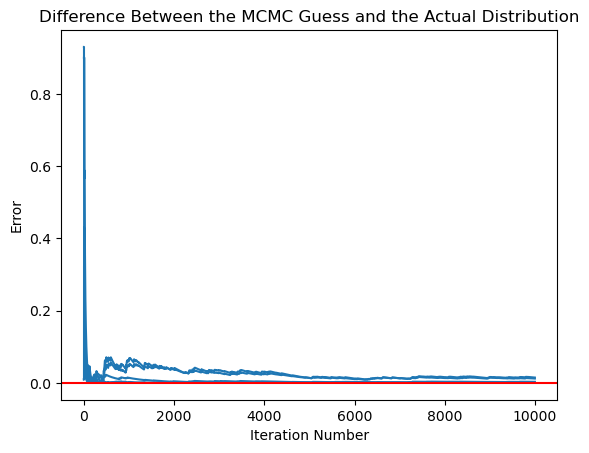

In [7]:
plt.plot([i for i in range(len(distance))], distance, c='C0')
plt.axhline(0, c='r')
plt.title('Difference Between the MCMC Guess and the Actual Distribution')
plt.xlabel('Iteration Number')
plt.ylabel('Error')

In [8]:
# computing region in circle

def region(x, y):
    if x**2+y**2<=1:     # in circle
        return 0
    if x>=0 and y>=0: # top left
        return 1
    elif x<0 and y>= 0: #top right
        return 2
    elif x<0 and y<0: #bottom left
        return 3
    else:                 # bottom right
        return 4


In [9]:
# mcmc sampling code

def mcmccircle(nsteps, target, step_size=0.2):
    x, y = 0.0, 0.0  # start at center
    samples = []

    for i in range(nsteps):
        xprop = x +np.random.normal(0, step_size) # propose a movement in x
        yprop = y +np.random.normal(0, step_size) # propose a movement in y
        if not (-1 <= xprop <= 1 and -1 <= yprop <= 1): # if outside, reject
            samples.append((x, y))
            continue
        rcurrent = region(x, y) # which region are you
        rprop = region(xprop, yprop) # which region is the propsed move
        alpha = min(1, target[rprop] / target[rcurrent]) # decide whether to move there

        if np.random.rand() < alpha:
            x, y = xprop, yprop

        samples.append((x, y))

    return np.array(samples)

In [10]:
# plotting code

def plotmcmc(samples):
    x = samples[:,0]
    y = samples[:,1]
    colors = []
    for i, j in zip(x, y):
        colors.append(region(i, j))
    plt.figure(figsize=(6,6))
    plt.scatter(x, y, c=colors, s=5)
    theta = np.linspace(0, 2*np.pi, 300)
    plt.plot(np.cos(theta), np.sin(theta))

    plt.title("MCMC on the Circle")
    plt.xlim([-1,1])
    plt.ylim([-1,1])
    plt.show()

In [11]:
target = [.9,.01,.01,.07,.01]
print(target)

[0.9, 0.01, 0.01, 0.07, 0.01]


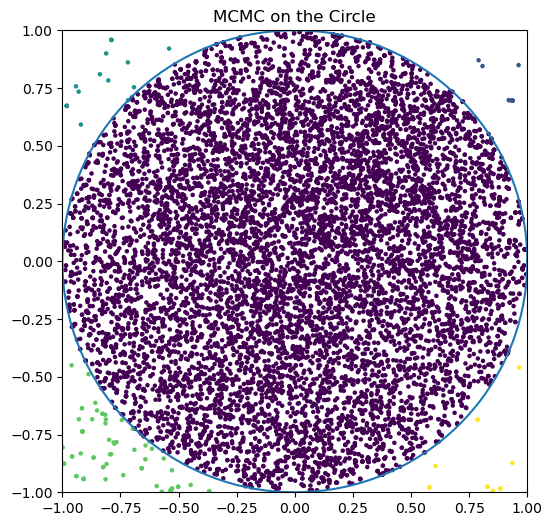

In [12]:
plotmcmc(mcmccircle(10000, target))

### Problem 1
Try running `mcmc` for 100, 1,000, and 10,000 steps to compare the estimates. What do you notices?

In [17]:
result = mcmc(100, target)
print(result)
print(type(result))
result = mcmc(1000, target)
print(result)
print(type(result))
result = mcmc(10000, target)
print(result)
print(type(result))

(array([3, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 3, 3, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]), [array([0.9 , 0.01, 0.01, 0.93, 0.01]), array([0.4 , 0.01, 0.01, 0.43, 0.01]), array([0.23333333, 0.01      , 0.01      , 0.26333333, 0.01      ]), array([0.15, 0.01, 0.01, 0.18, 0.01]), array([0.1 , 0.01, 0.01, 0.13, 0.01]), array([0.06666667, 0.01      , 0.01      , 0.09666667, 0.01      ]), array([0.04285714, 0.01      , 0.01      , 0.07285714, 0.01      ]), array([0.025, 0.01 , 0.01 , 0.055, 0.01 ]), array([0.01111111, 0.01      , 0.01      , 0.04111111, 0.01      ]), array([0.  , 0.01, 0.01, 0.03, 0.01]), array([0.00909091, 0.01      , 0.01      , 0.02090909, 0.01      ]), array([0.01666667, 0.01      , 0.01      , 0.01333333, 0.01      ]), array

### Problem 2
Write code that will run `mcmccircle()` until you have 1,000 points in the bottom right corner.

In [19]:
samples = mcmccircle(100, target)

In [22]:
count = 0

while count < 1000:
    samples = mcmccircle(100, target)

    for x, y in samples:
        if x > 0 and y < 0:
            count += 1

print(count)

1055


### Problem 3
Create your own `target` to be equal on all regions in `mcmc()`. Generate 100, 1,000, and 10,000 samples. Compare the averages of these runs. Do they converge?

In [50]:
def mcmc(steps, target):
    samples = []
    current = np.random.choice(len(target))
    for i in range(steps):
        proposal = np.random.choice(len(target))
        a = min(1, target[proposal] / target[current])
        if np.random.uniform(0,1) < a:
            current = proposal
        samples.append(current)
    return samples